In [1]:
# === SESSION BOOTSTRAP (run first in every notebook) ======================
from google.colab import drive
drive.mount('/content/drive')

import os, subprocess, sys

PARENT = "/content/drive/MyDrive/UAV_TRUST_Research"
REPO   = f"{PARENT}/uav-trust-research"

for fname in (".gitconfig", ".git-credentials"):
    src = os.path.join(PARENT, fname)
    if os.path.exists(src):
        subprocess.run(f'cp "{src}" /root/{fname}', shell=True)
subprocess.run("git config --global credential.helper store", shell=True)

r = subprocess.run("git config --global user.name && git config --global user.email",
                   shell=True, capture_output=True, text=True)
print("git identity:", r.stdout.strip() or "MISSING - run 00_setup.ipynb first")

if os.path.isdir(REPO):
    os.chdir(REPO)
    if REPO not in sys.path:
        sys.path.insert(0, REPO)
    print("cwd:", os.getcwd())
else:
    print("Repository not on Drive yet - run 00_setup.ipynb first.")

Mounted at /content/drive
git identity: Md Anas Biswas
anasbiswas@gmail.com
cwd: /content/drive/MyDrive/UAV_TRUST_Research/uav-trust-research


In [2]:
!pip install xgboost scikit-learn matplotlib pandas numpy scipy requests --quiet

In [3]:
# Configuration (corrected label, benign class, and leakage drops baked in)
CONFIG = {
    "zenodo_record": "15336998",
    "data_dir": "data/uavids2025",
    "label_col": "label",
    "normal_value": "Normal Traffic",
    "drop_col_patterns": ["unnamed", "flowid", "srcaddr", "dstaddr",
                           "srcport", "dstport", "index", "timestamp"],
    "conformal_alpha": 0.10,
    "n_ece_bins": 15,
    "bootstrap_B": 1000,
    "ci_alpha": 0.05,
    "seed": 42,
    "normal_fracs": {"train": 0.60, "cal": 0.20, "test_seen": 0.10, "test_shift": 0.10},
    "family_fracs": {"train": 0.60, "cal": 0.20, "test_seen": 0.20},
    "xgb": {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.1,
            "subsample": 0.9, "colsample_bytree": 0.9, "tree_method": "hist"},
    "fig_dir": "figures",
    "report_dir": "reports",
}
for d in [CONFIG["data_dir"], CONFIG["fig_dir"], CONFIG["report_dir"]]:
    os.makedirs(d, exist_ok=True)
CONFIG

{'zenodo_record': '15336998',
 'data_dir': 'data/uavids2025',
 'label_col': 'label',
 'normal_value': 'Normal Traffic',
 'drop_col_patterns': ['unnamed',
  'flowid',
  'srcaddr',
  'dstaddr',
  'srcport',
  'dstport',
  'index',
  'timestamp'],
 'conformal_alpha': 0.1,
 'n_ece_bins': 15,
 'bootstrap_B': 1000,
 'ci_alpha': 0.05,
 'seed': 42,
 'normal_fracs': {'train': 0.6,
  'cal': 0.2,
  'test_seen': 0.1,
  'test_shift': 0.1},
 'family_fracs': {'train': 0.6, 'cal': 0.2, 'test_seen': 0.2},
 'xgb': {'n_estimators': 300,
  'max_depth': 6,
  'learning_rate': 0.1,
  'subsample': 0.9,
  'colsample_bytree': 0.9,
  'tree_method': 'hist'},
 'fig_dir': 'figures',
 'report_dir': 'reports'}

In [4]:
# Imports (shared logic in src/)
import numpy as np, pandas as pd, requests, glob
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import (accuracy_score, f1_score,
                             balanced_accuracy_score, recall_score)
from src.trust import (top_label_ece, brier_binary, conformal_qhat, coverage_size,
                       aurc, bootstrap_ci, logit, fit_calibrators, apply_calibrators)
from src.data import load_csvs, detect_schema, prepare_splits
np.random.seed(CONFIG["seed"])
print("imports ready")

imports ready


In [5]:
# Ensure dataset present (download only if missing), then load
rec = CONFIG["zenodo_record"]
if not glob.glob(os.path.join(CONFIG["data_dir"], "**/*.csv"), recursive=True):
    meta = requests.get(f"https://zenodo.org/api/records/{rec}", timeout=60).json()
    for f in meta.get("files", []):
        name, url = f["key"], f["links"]["self"]
        if name.lower().endswith((".csv", ".zip", ".gz")):
            open(os.path.join(CONFIG["data_dir"], name), "wb").write(requests.get(url, timeout=600).content)
    for z in glob.glob(os.path.join(CONFIG["data_dir"], "*.zip")):
        import zipfile; zipfile.ZipFile(z).extractall(CONFIG["data_dir"])
df = load_csvs(CONFIG["data_dir"])
label_col, normal_value, families = detect_schema(df, CONFIG["label_col"], CONFIG["normal_value"])
print("shape:", df.shape)
print("families to hold out in turn:", families)

shape: (122171, 23)
families to hold out in turn: ['Sybil Attack', 'Blackhole Attack', 'Wormhole Attack', 'Flooding Attack']


In [6]:
# Evaluate with each attack family held out in turn
results, store = [], {}
alpha, nb = CONFIG["conformal_alpha"], CONFIG["n_ece_bins"]
for F in families:
    S = prepare_splits(df, label_col, normal_value, F, CONFIG["drop_col_patterns"],
                       CONFIG["normal_fracs"], CONFIG["family_fracs"], CONFIG["seed"])
    clf = xgb.XGBClassifier(objective="binary:logistic", eval_metric="logloss",
                            random_state=CONFIG["seed"], **CONFIG["xgb"])
    clf.fit(S["X_train"], S["y_train"])

    def sc(X):
        p = clf.predict_proba(X)[:, 1]; return p, logit(p)
    p_cal, lg_cal   = sc(S["X_cal"])
    p_seen, lg_seen = sc(S["X_seen"])
    p_shift, lg_shift = sc(S["X_shift"])
    y_seen, y_shift = S["y_seen"], S["y_shift"]

    fitted = fit_calibrators(lg_cal, p_cal, S["y_cal"])
    cs = apply_calibrators(fitted, lg_seen, p_seen)
    ch = apply_calibrators(fitted, lg_shift, p_shift)
    qhat = conformal_qhat(p_cal, S["y_cal"], alpha=alpha)

    pr_s = (p_seen >= 0.5).astype(int)
    pr_h = (p_shift >= 0.5).astype(int)
    results.append({
        "held_out": F,
        # detection (honest metrics for the imbalanced shift set)
        "shift_heldout_recall": recall_score(y_shift, pr_h, pos_label=1),
        "shift_trivial_base": max(np.mean(y_shift == 0), np.mean(y_shift == 1)),
        "seen_macroF1": f1_score(y_seen, pr_s, average="macro"),
        "shift_macroF1": f1_score(y_shift, pr_h, average="macro"),
        "seen_balacc": balanced_accuracy_score(y_seen, pr_s),
        "shift_balacc": balanced_accuracy_score(y_shift, pr_h),
        "shift_acc_raw": accuracy_score(y_shift, pr_h),
        # trust
        "seen_ECE_temp": top_label_ece(cs["temperature"], y_seen, nb),
        "shift_ECE_temp": top_label_ece(ch["temperature"], y_shift, nb),
        "shift_ECE_raw": top_label_ece(ch["raw"], y_shift, nb),
        "shift_Brier_temp": brier_binary(ch["temperature"], y_shift),
        "seen_coverage": coverage_size(p_seen, y_seen, qhat)[0],
        "shift_coverage": coverage_size(p_shift, y_shift, qhat)[0],
        "seen_AURC": aurc(np.maximum(p_seen, 1 - p_seen), (pr_s == y_seen).astype(float))[0],
        "shift_AURC": aurc(np.maximum(p_shift, 1 - p_shift), (pr_h == y_shift).astype(float))[0],
        "T": fitted["temperature"],
    })
    store[F] = dict(p_seen=p_seen, y_seen=y_seen, p_shift=p_shift, y_shift=y_shift,
                    ts=cs["temperature"], th=ch["temperature"], qhat=qhat)
    print("done:", F)

done: Sybil Attack
done: Blackhole Attack
done: Wormhole Attack
done: Flooding Attack


In [7]:
# Detection summary (lead with balanced accuracy and held-out recall, not raw accuracy)
res = pd.DataFrame(results)
det = ["held_out", "shift_heldout_recall", "shift_trivial_base",
       "seen_macroF1", "shift_macroF1", "seen_balacc", "shift_balacc", "shift_acc_raw"]
print(res[det].round(4).to_string(index=False))

        held_out  shift_heldout_recall  shift_trivial_base  seen_macroF1  shift_macroF1  seen_balacc  shift_balacc  shift_acc_raw
    Sybil Attack                0.9963              0.9019        0.9924         0.9887       0.9947        0.9947         0.9960
Blackhole Attack                0.4891              0.9089        0.9928         0.4687       0.9943        0.7421         0.5352
 Wormhole Attack                0.8232              0.9088        0.9999         0.7174       1.0000        0.9116         0.8393
 Flooding Attack                0.9952              0.8828        0.9914         0.9879       0.9938        0.9942         0.9949


In [8]:
# Trust summary (calibration, conformal coverage, selective risk)
trust = ["held_out", "seen_ECE_temp", "shift_ECE_temp", "shift_ECE_raw",
         "shift_Brier_temp", "seen_coverage", "shift_coverage",
         "seen_AURC", "shift_AURC", "T"]
print(res[trust].round(4).to_string(index=False))

        held_out  seen_ECE_temp  shift_ECE_temp  shift_ECE_raw  shift_Brier_temp  seen_coverage  shift_coverage  seen_AURC  shift_AURC      T
    Sybil Attack         0.0004          0.0033         0.0033            0.0039         0.9131          0.9495        0.0      0.0001 1.0287
Blackhole Attack         0.0012          0.3739         0.3831            0.3584         0.9125          0.4078        0.0      0.1832 1.1157
 Wormhole Attack         0.0001          0.1353         0.1289            0.1437         0.9166          0.6373        0.0      0.0336 0.7909
 Flooding Attack         0.0008          0.0105         0.0095            0.0057         0.9095          0.7363        0.0      0.0001 1.0587


In [9]:
# Bootstrap 95% CIs on the metrics that carry the argument, per held-out family
B, seed, a = CONFIG["bootstrap_B"], CONFIG["seed"], CONFIG["ci_alpha"]
def fmt(m): return "%.4f [%.4f, %.4f]" % m
ci_rows = []
for F in families:
    d = store[F]
    qh = d["qhat"]
    mf1 = lambda p, y: f1_score(y, (p >= 0.5).astype(int), average="macro")
    bac = lambda p, y: balanced_accuracy_score(y, (p >= 0.5).astype(int))
    ece = lambda p, y: top_label_ece(p, y, CONFIG["n_ece_bins"])
    cov = lambda p, y: coverage_size(p, y, qh)[0]
    specs = [("macro-F1", mf1, (d["p_seen"], d["y_seen"]), (d["p_shift"], d["y_shift"])),
             ("balanced-acc", bac, (d["p_seen"], d["y_seen"]), (d["p_shift"], d["y_shift"])),
             ("ECE(temp)", ece, (d["ts"], d["y_seen"]), (d["th"], d["y_shift"])),
             ("coverage", cov, (d["p_seen"], d["y_seen"]), (d["p_shift"], d["y_shift"]))]
    for name, fn, sa, ha in specs:
        ci_rows.append({"held_out": F, "metric": name,
                        "seen": fmt(bootstrap_ci(fn, *sa, B=B, seed=seed, alpha=a)),
                        "shift": fmt(bootstrap_ci(fn, *ha, B=B, seed=seed, alpha=a))})
ci = pd.DataFrame(ci_rows)
print(ci.to_string(index=False))

        held_out       metric                    seen                   shift
    Sybil Attack     macro-F1 0.9923 [0.9904, 0.9941] 0.9887 [0.9867, 0.9908]
    Sybil Attack balanced-acc 0.9946 [0.9929, 0.9963] 0.9947 [0.9930, 0.9962]
    Sybil Attack    ECE(temp) 0.0010 [0.0005, 0.0016] 0.0034 [0.0027, 0.0041]
    Sybil Attack     coverage 0.9131 [0.9089, 0.9174] 0.9494 [0.9468, 0.9520]
Blackhole Attack     macro-F1 0.9928 [0.9910, 0.9944] 0.4688 [0.4633, 0.4743]
Blackhole Attack balanced-acc 0.9943 [0.9924, 0.9960] 0.7421 [0.7388, 0.7452]
Blackhole Attack    ECE(temp) 0.0014 [0.0009, 0.0021] 0.3739 [0.3685, 0.3792]
Blackhole Attack     coverage 0.9125 [0.9078, 0.9168] 0.4079 [0.4023, 0.4135]
 Wormhole Attack     macro-F1 0.9999 [0.9997, 1.0000] 0.7174 [0.7107, 0.7242]
 Wormhole Attack balanced-acc 1.0000 [0.9999, 1.0000] 0.9116 [0.9094, 0.9140]
 Wormhole Attack    ECE(temp) 0.0001 [0.0000, 0.0002] 0.1354 [0.1312, 0.1393]
 Wormhole Attack     coverage 0.9166 [0.9124, 0.9206] 0.6373 [0.

In [10]:
# Save result tables
res.to_csv(os.path.join(CONFIG["report_dir"], "02_multifamily_summary.csv"), index=False)
ci.to_csv(os.path.join(CONFIG["report_dir"], "02_multifamily_ci.csv"), index=False)
print("saved 02_multifamily_summary.csv and 02_multifamily_ci.csv to", CONFIG["report_dir"])

saved 02_multifamily_summary.csv and 02_multifamily_ci.csv to reports


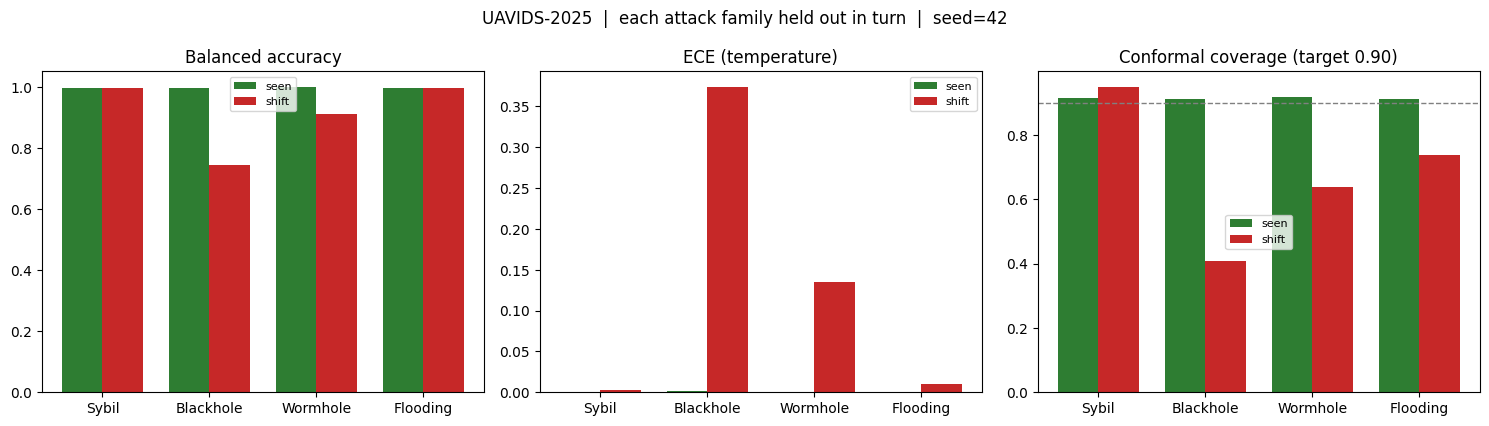

In [11]:
# Figure: does the pattern replicate across all four held-out families
fams = res["held_out"].tolist()
labels = [f.replace(" Attack", "") for f in fams]
x = np.arange(len(fams)); w = 0.38
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
def panel(a, seen_col, shift_col, title, target=None):
    a.bar(x - w/2, res[seen_col], w, label="seen", color="#2e7d32")
    a.bar(x + w/2, res[shift_col], w, label="shift", color="#c62828")
    a.set_xticks(x); a.set_xticklabels(labels); a.set_title(title); a.legend(fontsize=8)
    if target is not None:
        a.axhline(target, ls="--", color="gray", lw=1)
panel(ax[0], "seen_balacc", "shift_balacc", "Balanced accuracy")
panel(ax[1], "seen_ECE_temp", "shift_ECE_temp", "ECE (temperature)")
panel(ax[2], "seen_coverage", "shift_coverage", "Conformal coverage (target 0.90)",
      target=1 - CONFIG["conformal_alpha"])
fig.suptitle("UAVIDS-2025  |  each attack family held out in turn  |  seed=%d" % CONFIG["seed"])
fig.tight_layout()
fig.savefig(os.path.join(CONFIG["fig_dir"], "02_multifamily.png"), dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Commit results (end-of-unit discipline)
!git add reports/ figures/ notebooks/
!git commit -m "02 UAVIDS-2025: multi-family held-out trust evaluation (all four families, balanced metrics, bootstrap CIs)"
!git push origin main

[main 57bbd0f] 02 UAVIDS-2025: multi-family held-out trust evaluation (all four families, balanced metrics, bootstrap CIs)
 11 files changed, 36 insertions(+)
 create mode 100644 figures/01_confidence_shift.png
 create mode 100644 figures/01_detection_vs_trust.png
 create mode 100644 figures/01_reliability.png
 create mode 100644 figures/02_multifamily.png
 create mode 100644 notebooks/00_setup.ipynb
 create mode 100644 notebooks/01_uavids_heldout_trust.ipynb
 create mode 100644 notebooks/02_uavids_multifamily.ipynb
 create mode 100644 reports/01_bootstrap_results.csv
 create mode 100644 reports/01_calibration_table.csv
 create mode 100644 reports/02_multifamily_ci.csv
 create mode 100644 reports/02_multifamily_summary.csv
Enumerating objects: 20, done.
Counting objects: 100% (18/18), done.
Delta compression using up to 2 threads
Compressing objects: 100% (16/16), done.
Writing objects: 100% (16/16), 303.03 KiB | 2.75 MiB/s, done.
Total 16 (delta 0), reused 0 (delta 0), pack-reused 0
T